# IMPORT

In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
print(os.getcwd())

/Users/maugeear/Documents/UTC 2022-2027/GI04/SY09/PROJET SY09


# FONCTIONS

In [14]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    dendrogram(linkage_matrix, **kwargs)

In [7]:
X_scaled = pd.read_csv("donnees/X_scaled_mat.csv")

### Trouver le K

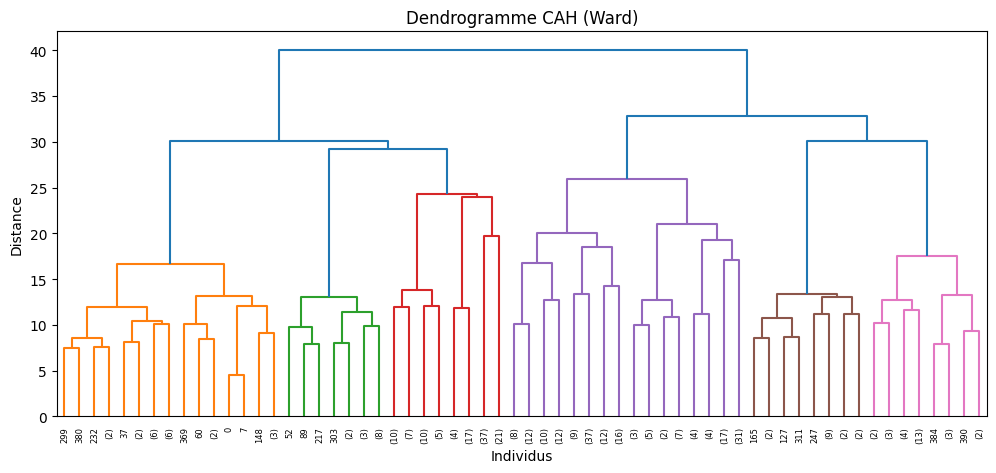

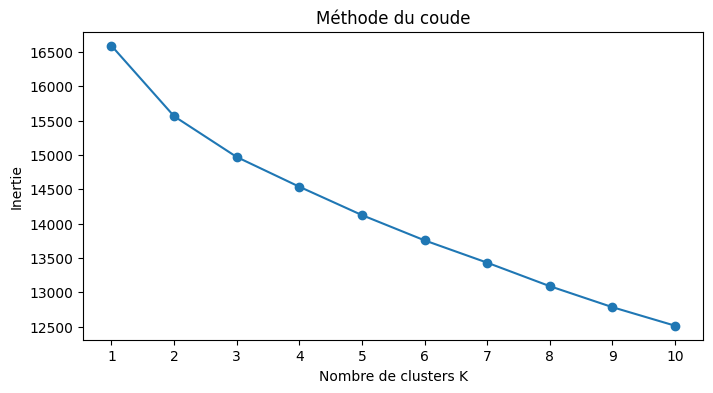

In [16]:
cah = AgglomerativeClustering(
    metric='euclidean',
    linkage='ward',        # critère de Ward recommandé pour données quantitatives
    compute_distances=True
)
cah.fit(X_scaled)

plt.figure(figsize=(12, 5))
plot_dendrogram(cah, truncate_mode='level', p=5)
plt.title('Dendrogramme CAH (Ward)')
plt.xlabel('Individus')
plt.ylabel('Distance')
plt.show()

# ---- Méthode du coude ----
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.xticks(K_range)
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
plot_dendrogram(cah, truncate_mode='level', p=5)
plt.title('Dendrogramme CAH (Ward)')
plt.xlabel('Individus')
plt.ylabel('Distance')
plt.show()

### K-means 

In [10]:
K = 2

kmeans = KMeans(
    n_clusters=K,          # K issu de la CAH
    init='k-means++',      # initialisation plus stable que 'random'
    n_init=10,
    random_state=42
)
kmeans.fit(X_scaled)
labels = kmeans.labels_